In [1]:
import scanpy as sc
import pandas as pd

import sys, os

import matplotlib.pyplot as plt
import palettable
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR


In [ ]:
import os, sys
from pathlib import Path
os.chdir('../../data')
sys.path.insert(0, str(Path("../..").resolve()))

In [3]:

d10_lapa_eecs = sc.read_h5ad(ANALYSIS_DIR / "data-objects/cellassign/d10_lapa_predictions.h5ad")

In [ ]:
d10_lapa_eecs

AnnData object with n_obs × n_vars = 33507 × 22
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'size_factor', '_scvi_batch', 'cell_assign_prob_ISCs', 'cell_assign_prob_PCs', 'cell_assign_prob_Proliferating PCs', 'cell_assign_prob_Secretory PCs', 'cell_assign_prob_Enterocytes', 'cell_assign_prob_Goblet cells', 'cell_assign_prob_EECs', 'initial_cellassign_predictions', 'initial_cellassign_prediction', 'cellassign_confidence', 'extended_cellassign_prediction', 'cell_assign_prob_T-Epithelial doublet', 'cell_assign_prob_Epithelial Progenitor', 'cell_assign_prob_plasma-epi doublet', 'cell_assign_prob_Enteroendocrine Cell', 'cell_assign_prob_Goblet Cells', 'cell_assign_prob_Early Enterocyte', 'cell_assign_prob_Late Enterocyte', 'cell_assign_prob_Tuft Cell', 'cell_assign_prob_BEST4+ Enterocyte', 'cell_assign_prob_Myeloid-Epithelial Doublet', 'cell_assign_prob_REG1A(-) INF-stim prog', 'cell_as

In [ ]:
d10_lapa_eecs.obs['orig.ident']

AAACCAAAGGGTATGG-1    D10_Lapa
AAACCAAAGGTTCAGC-1    D10_Lapa
AAACCAAAGTAATGGA-1    D10_Lapa
AAACCAAAGTCAGCAC-1    D10_Lapa
AAACCAAAGTGCGCTG-1    D10_Lapa
                        ...   
TGTGTTGAGGCGCTCA-1    D10_Lapa
TGTGTTGAGGGTGAAT-1    D10_Lapa
TGTGTTGAGTAGAGCG-1    D10_Lapa
TGTGTTGAGTAGCGTC-1    D10_Lapa
TGTGTTGAGTCGCGCA-1    D10_Lapa
Name: orig.ident, Length: 33507, dtype: category
Categories (1, object): ['D10_Lapa']

In [ ]:
# === Tell the plots where to find things in adata.obs ===
CFG = {
    "stage_key":   "orig.ident",            # e.g. "Stage", "Week", "Batch", "Condition"
    "label_key":   "initial_cellassign_prediction",   # your curated labels
    "cluster_key": "leiden",           # your unsupervised clusters
}

# Optional: rename internal labels -> pretty display labels (per your dataset)
DISPLAY_NAME = {
    # "Beta_like":"SC-β", "Alpha_like":"SC-α",  # example only—use your names
}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from palettable.cartocolors.qualitative import Bold_10, Vivid_10

def set_category_order(adata, key, order=None):
    s = adata.obs[key].astype("category")
    if order is None:
        order = list(s.cat.categories)  # keep current order
    adata.obs[key] = s.cat.reorder_categories(order, ordered=True)
    return order

def make_palette(categories, colors=None, base="bold"):
    """colors: optional dict {category: color}; otherwise palettable fallback."""
    if colors:
        # fill missing categories from a base palette
        remaining = [c for c in categories if c not in colors]
        base_colors = {"bold": Bold_10.mpl_colors, "vivid": Vivid_10.mpl_colors}[base]
        reps = int(np.ceil(len(remaining) / len(base_colors)))
        cyc = (base_colors * reps)[: len(remaining)]
        merged = {**colors}
        for cat, col in zip(remaining, cyc):
            merged[cat] = col
        return merged
    else:
        base_colors = {"bold": Bold_10.mpl_colors, "vivid": Vivid_10.mpl_colors}[base]
        reps = int(np.ceil(len(categories) / len(base_colors)))
        cyc = (base_colors * reps)[: len(categories)]
        return {cat: cyc[i] for i, cat in enumerate(categories)}

def display_names(series, mapping):
    """Map internal labels to pretty names (no-op if mapping is empty)."""
    if not mapping:
        return series
    return series.map(lambda x: mapping.get(x, x))


In [ ]:
def umap_scatter(
    adata, groupby, order=None, palette=None,
    title=None, subtitle=None, point_size=4, alpha=0.95,
    legend_ncol=3, figsize=(6,6),
):
    order = set_category_order(adata, groupby, order)
    palette = palette or make_palette(order, base="bold")

    X = adata.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=figsize)
    for cat in order:
        m = (adata.obs[groupby] == cat).values
        ax.scatter(X[m,0], X[m,1], s=point_size, lw=0, alpha=alpha, c=[palette[cat]], label=cat)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    if title:    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=6)
    if subtitle: ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10)

    ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.0), frameon=False,
              ncol=legend_ncol, fontsize=9, handletextpad=0.3, columnspacing=0.8)
    plt.tight_layout()
    return fig, ax, order, palette

def population_strip(adata, groupby, order, palette, ax=None, label="Population ratios:"):
    counts = adata.obs[groupby].value_counts().reindex(order).fillna(0)
    fracs = counts / counts.sum()
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,0.6))
    left = 0.0
    for cat in order:
        w = float(fracs[cat])
        ax.barh(0, w, left=left, height=0.8, color=palette[cat])
        left += w
    ax.set_xlim(0,1); ax.set_ylim(-0.5,1.5); ax.axis("off")
    ax.text(0, 0.0, label, ha="left", va="center", fontsize=9)
    return ax


In [ ]:
def panel_clusters(adata, stage_value=None, cfg=CFG, order=None, palette=None, save=None):
    """UMAP colored by unsupervised clusters, optionally for one stage."""
    ad = adata
    if stage_value is not None:
        ad = adata[adata.obs[cfg["stage_key"]].astype(str) == str(stage_value)].copy()
    title = str(stage_value) if stage_value is not None else None
    subtitle = f"({ad.n_obs:,} cells)"

    fig, ax, order, palette = umap_scatter(
        ad, groupby=cfg["cluster_key"], order=order, palette=palette,
        title=title, subtitle=subtitle, legend_ncol=4
    )
    population_strip(ad, cfg["cluster_key"], order, palette,
                     ax=fig.add_axes([0.12, 0.07, 0.76, 0.08]))
    if save: fig.savefig(save, bbox_inches="tight")
    return fig

def panel_labels(adata, stage_value=None, cfg=CFG, label_order=None, label_colors=None, save=None):
    """UMAP colored by curated labels (you choose the column)."""
    ad = adata
    if stage_value is not None:
        ad = adata[adata.obs[cfg["stage_key"]].astype(str) == str(stage_value)].copy()

    # Optional pretty names
    key = cfg["label_key"]
    if "__pretty__" not in ad.obs:
        ad.obs["__pretty__"] = display_names(ad.obs[key], DISPLAY_NAME)

    order = set_category_order(ad, "__pretty__", label_order)
    palette = make_palette(order, colors=label_colors, base="vivid")

    fig, ax, order, palette = umap_scatter(
        ad, groupby="__pretty__", order=order, palette=palette,
        title=str(stage_value) if stage_value is not None else None,
        subtitle=f"({ad.n_obs:,} cells)", legend_ncol=3
    )
    population_strip(ad, "__pretty__", order, palette,
                     ax=fig.add_axes([0.12, 0.07, 0.76, 0.08]))
    if save: fig.savefig(save, bbox_inches="tight")
    return fig


In [ ]:
d10_lapa_eecs.obs[CFG["label_key"]].unique()


['REG1A(+) INF-stim prog', 'CCL25+ Epithelial Cell', 'Enteroendocrine Cell', 'Tuft Cell', 'plasma-epi doublet', ..., 'M Cell', 'BEST4+ Enterocyte', 'Late Enterocyte', 'Epithelial Progenitor', 'Early Enterocyte']
Length: 16
Categories (16, object): ['BEST4+ Enterocyte', 'CCL25+ Epithelial Cell', 'DUOX2+ Activated Enterocyte', 'Early Enterocyte', ..., 'REG1A(-) INF-stim prog', 'T-Epithelial doublet', 'Tuft Cell', 'plasma-epi doublet']

In [ ]:
LABEL_ORDER = [
    "ISCs", "PCs", "EECs", "Enterocytes", "Goblet", "TA", "Other"
]

LABEL_COLORS = {
    "ISCs": "#8dd3c7",
    "PCs": "#fb8072",
    "EECs": "#80b1d3",
    "Enterocytes": "#fdb462",
    "Goblet": "#b3de69",
    "TA": "#fccde5",
    "Other": "#d9d9d9"
}


In [ ]:
def umap_scatter_pretty(
    adata,
    groupby,
    order=None,
    palette=None,
    title=None,
    subtitle=None,
    point_size=5,
    alpha=0.9,
    edge_color="k",
    edge_width=0.15,
    legend_ncol=3,
    figsize=(6,6),
):
    order = set_category_order(adata, groupby, order)
    if palette is None:
        palette = make_palette(order, base="vivid")

    X = adata.obsm["X_umap"]
    fig, ax = plt.subplots(figsize=figsize)

    for cat in order:
        mask = (adata.obs[groupby] == cat).values
        ax.scatter(
            X[mask,0],
            X[mask,1],
            s=point_size,
            c=[palette[cat]],
            edgecolors=edge_color,
            linewidths=edge_width,
            alpha=alpha,
            rasterized=True,   # speeds up PDF export
            label=cat
        )

    # clean styling
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_aspect("equal", adjustable="box")

    # titles
    if title:
        ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=4)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10)

    # legend
    leg = ax.legend(
        loc="upper left", bbox_to_anchor=(0,1), frameon=False,
        ncol=legend_ncol, fontsize=9, handletextpad=0.3, columnspacing=0.8
    )
    for txt in leg.get_texts():
        # italicize anything that looks like a gene symbol
        if any(ch.isupper() for ch in txt.get_text()):
            txt.set_fontstyle("italic")

    plt.tight_layout()
    return fig, ax, order, palette


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as PathEffects
import numpy as np
from palettable.colorbrewer.qualitative import Set1_9, Pastel1_9, Set3_12, Set2_8

# ===== base color sequence =====
VERES_COLORS = (
    Set1_9.colors +
    Pastel1_9.colors +
    Set3_12.colors +
    Set2_8.colors
)

# --- generic categorical scatter (Veres style)
def scatter_cat_umap(pos, cat, title='', ax=None,
                     min_elements_for_label=0,
                     color_sequence=None,
                     s=3, alpha=1.0):
    color_sequence = color_sequence or VERES_COLORS
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.5,3.5))
    ax.set_title(title, fontsize=10, fontweight='bold', loc='left')

    unique_cats = sorted(set(cat))
    for col, cval in zip(color_sequence, unique_cats):
        mask = (cat == cval)
        rgb = np.array(col)/255.
        ax.scatter(pos[mask,0], pos[mask,1],
                   c=[rgb], s=s, lw=0, alpha=alpha, rasterized=True)
    # Label each category at median position (with white outline)
    for cval in unique_cats:
        mask = (cat == cval)
        if mask.sum() > min_elements_for_label:
            x, y = np.median(pos[mask,0]), np.median(pos[mask,1])
            txt = ax.text(x, y, str(cval), ha='center', va='center', fontweight='bold', fontsize=7)
            txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal'); ax.axis('off')
    return ax


<Axes: title={'left': 'D10_Lapa'}>

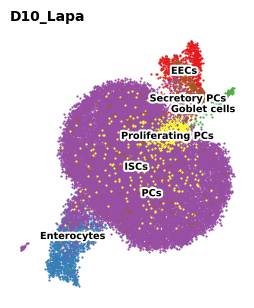

In [ ]:
pos = d10_lapa_eecs.obsm['X_umap']
labels = d10_lapa_eecs.obs['initial_cellassign_prediction']

fig, ax = plt.subplots(figsize=(3.5,3.5))
scatter_cat_umap(pos, labels, title="D10_Lapa", ax=ax, s=2.5)


In [ ]:
# --- Veres-style panel builder (Scanpy/AnnData) ---

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
from collections import Counter, OrderedDict
from sklearn.neighbors import NearestNeighbors
from palettable.colorbrewer.qualitative import Set1_9, Paired_10, Set2_8

# -------------------- typography to match paper --------------------
def setup_matplotlib_params():
    from matplotlib import rcParams
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans']
    rcParams['axes.titlesize'] = 5
    rcParams['axes.labelsize']  = 5
    rcParams['xtick.labelsize'] = 5
    rcParams['ytick.labelsize'] = 5
    rcParams['axes.linewidth']  = 0.5
    rcParams['xtick.major.width'] = 0.5
    rcParams['ytick.major.width'] = 0.5
    rcParams['pdf.fonttype'] = 42  # editable text in Illustrator

setup_matplotlib_params()

# -------------------- core color registry (as in figure_vis.py) --------------------
def _col(x): return np.array(x)/255.

class CoreColors:
    def __init__(self):
        base = dict(zip(
            ['red','blue','green','purple','orange','yellow','brown','pink','grey'],
            Set1_9.colors
        ))
        for k,v in base.items(): setattr(self, k, _col(v))
        for name,c in zip(['blue','green','red','orange','purple'], Paired_10.colors[::2]):
            setattr(self, 'pale_'+name, _col(c))
        self.teal        = _col(Set2_8.colors[0])
        self.pale_brown  = _col([193,128,108])
        self.light_grey  = _col(Set2_8.colors[-1])
        self.dark_green  = _col([52,117,50])
        self.dark_grey   = np.array([0.5,0.5,0.5])

core_colors = CoreColors()

# -------------------- label params (you can fully customize) --------------------
def make_label_params(category_names):
    """
    Build a label->dict(color, short_label) map deterministically from the
    Veres palettes. Edit this to hard-code exact colors if desired.
    """
    palette = (
        Set1_9.colors + Paired_10.colors[::2] + Set2_8.colors
    )
    lp = OrderedDict()
    for name, col in zip(category_names, palette):
        lp[name] = dict(color=_col(col), short_label=name)
    return lp

# -------------------- identical logic: sort to put homogeneous neighborhoods on top --------------------
def prepare_for_scatter(X, labels, label_params):
    labels = np.asarray(labels)
    nbrs = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(X)
    knn = nbrs.kneighbors(X, return_distance=False)
    # fraction of neighbors with the same label; sort so dense/consistent are on top
    same = (labels[knn].T == labels[knn][:,0].T).mean(0)
    order = np.argsort(same)
    # map labels -> RGB
    colors = np.ones((len(labels),3))*0.5
    for k,v in label_params.items():
        colors[labels==k] = v['color']
    return X[order], colors[order]

# -------------------- the panel function (ports the notebook code) --------------------
def plot_veres_panel(
    adata,
    label_key,                 # e.g. "initial_cellassign_prediction_colors"
    stage_text=None,           # e.g. "D10_Lapa"
    ratio_order=None,          # list specifying order in pop-bar (optional)
    label_order=None,          # legend order (optional)
    save=None,                 # path to .pdf/.png
    dpi=600
):
    # coords & labels
    X = adata.obsm['X_umap']
    labels = adata.obs[label_key].astype(str).values
    cats = list(pd.unique(labels)) if label_order is None else label_order

    # label params (color + short label)
    lp = make_label_params(cats)

    # ===== panel sizing exactly like their notebook =====
    mm_per_inch = 25.4
    panel_size_in = ((89/2)/mm_per_inch, 25.4/mm_per_inch)  # (W, H)
    cell_pop_bar_h = 0.07
    heights = ((1 - cell_pop_bar_h)*panel_size_in[1], cell_pop_bar_h*panel_size_in[1])
    widths  = (panel_size_in[0] - heights[0], heights[0])  # legend column narrower than scatter

    fig = plt.figure(figsize=panel_size_in, dpi=dpi)
    gs  = gridspec.GridSpec(2, 2, fig, 0,0,1,1,
                            hspace=0, wspace=0,
                            width_ratios=widths, height_ratios=heights)

    # ===== left column: title + legend (with colored dots) =====
    ax = fig.add_subplot(gs[0,0], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)
    li = 1
    yl = lambda i: 1 - i/10.5
    xl_dot, xl_head, xl_text = 0.22, 0.30, 0.30

    # Title ("Stage X" in Veres; we show stage_text and n_cells)
    if stage_text is None:
        stage_text = ""
    ax.text(xl_head, yl(li), f"{stage_text}", va='center', fontsize=6, fontweight='extra bold', clip_on=False)
    li += 1
    ax.text(xl_head, yl(li), f"({adata.n_obs:,} cells)", va='center', fontsize=5, clip_on=False)
    li += 1.5

    present = [c for c in (label_order or cats) if c in set(labels)]
    for lb in present:
        lb_txt = lp[lb]['short_label']
        ax.scatter(xl_dot, yl(li)+0.008, s=15, c=lp[lb]['color'].reshape(1,-1), clip_on=False)
        for line in str(lb_txt).splitlines():
            ax.text(xl_text, yl(li), line, va='center', fontsize=5, clip_on=False)
            li += 1

    # ===== right column: layered scatter (black -> white -> color), alpha as in notebook =====
    proj, rgb = prepare_for_scatter(X, labels, lp)
    ax = fig.add_subplot(gs[0,1], xticks=[], yticks=[], frameon=False, zorder=-1)
    ax.patch.set_visible(False)

    s_black, s_white, s_type = 4, 2, 1.5   # EXACT dot sizes used in the notebook
    ax.scatter(proj[:,0], proj[:,1], c='k', edgecolor='none', s=s_black, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c='w', edgecolor='none', s=s_white, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c=rgb, edgecolor='none', s=s_type, alpha=0.7, rasterized=True)

    # ===== bottom row: population ratio bar (with border rectangle and label) =====
    ax = fig.add_subplot(gs[1,0:2], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)

    counts = pd.Series(Counter(labels))
    fracs  = counts / counts.sum()
    rr = ratio_order or present  # if no ratio_order, follow legend order

    cumul = 0.0
    for lb in rr:
        if lb in fracs:
            w = float(fracs[lb])
            ax.add_patch(patches.Rectangle((0.30 + 0.68*cumul, 0.02), 0.68*w, 1.0,
                                           facecolor=lp[lb]['color'], edgecolor='none', clip_on=False))
            cumul += w

    ax.text(0.175, 0.5, 'Pop. ratios:', va='center', ha='center', fontsize=5, clip_on=False)
    ax.add_patch(patches.Rectangle((0.30, 0.02), 0.68, 1.0, facecolor='none', edgecolor='k', linewidth=0.5, clip_on=False))

    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=dpi, transparent=True, bbox_inches='tight')
    return fig


/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_6805/2235168765.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


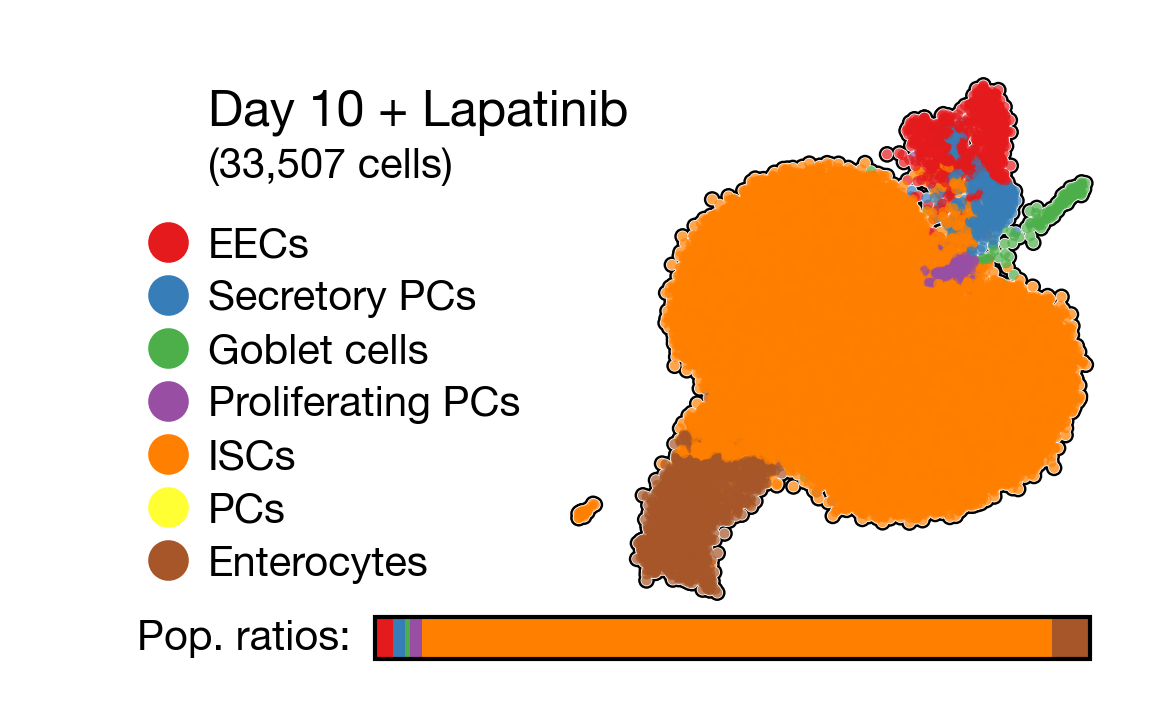

In [ ]:
# Your schema
STAGE = "D10_Lapa"
LABEL_KEY = "initial_cellassign_prediction"  # or your final label column

# Optional: lock display order (legend + pop-bar) to your preferred sequence
label_order = [
    "EECs", "Secretory PCs", "Goblet cells",
    "Proliferating PCs", "ISCs", "PCs", "Enterocytes"
]
ratio_order = label_order  # can be different if you wish

# Subset if you had multiple stages; otherwise just pass your AnnData
fig = plot_veres_panel(
    d10_lapa_eecs, 
    label_key=LABEL_KEY,
    stage_text="Day 10 + Lapatinib",
    label_order=label_order,   # or None to use dataset order
    ratio_order=ratio_order   # or None
)


In [ ]:
## How about gray instead of orange

# --- Patch to override one label color ---
def patch_label_color_to_gray(label_params, target_label="ISCs", gray_hex="#9E9E9E"):
    """Replace a specific label color with a gray tone."""
    if target_label in label_params:
        h = gray_hex.lstrip("#")
        gray_rgb = np.array([int(h[i:i+2], 16) for i in (0, 2, 4)]) / 255.0
        label_params[target_label]["color"] = gray_rgb
    return label_params


/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_6805/2235168765.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


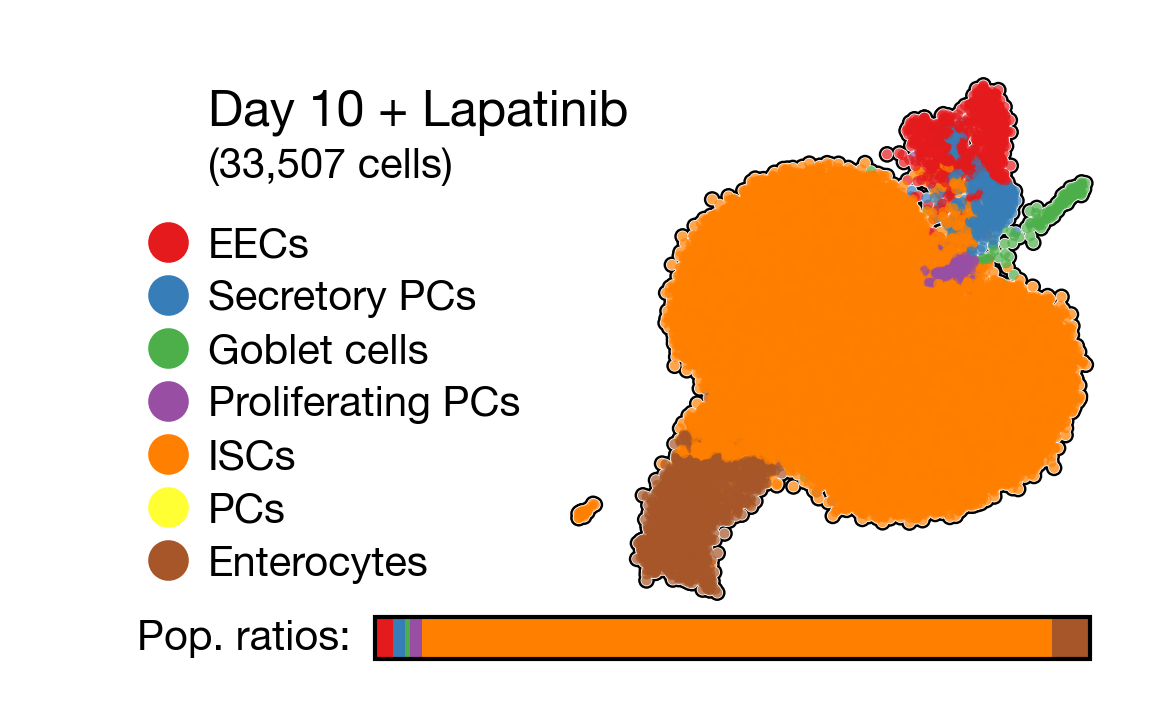

In [ ]:
cats = ["EECs", "Secretory PCs", "Goblet cells",
        "Proliferating PCs", "ISCs", "PCs", "Enterocytes"]

lp = make_label_params(cats)
lp = patch_label_color_to_gray(lp, "ISCs", gray_hex="#9E9E9E")

fig = plot_veres_panel(
    d10_lapa_eecs,
    label_key="initial_cellassign_prediction",
    stage_text="Day 10 + Lapatinib",
    label_order=cats,
    ratio_order=cats
)


In [ ]:
# --- Veres-style panel builder (Scanpy/AnnData) ---

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
from collections import Counter, OrderedDict
from sklearn.neighbors import NearestNeighbors
from palettable.colorbrewer.qualitative import Set1_9, Paired_10, Set2_8

# -------------------- typography to match paper --------------------
def setup_matplotlib_params():
    from matplotlib import rcParams
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans']
    rcParams['axes.titlesize'] = 5
    rcParams['axes.labelsize']  = 5
    rcParams['xtick.labelsize'] = 5
    rcParams['ytick.labelsize'] = 5
    rcParams['axes.linewidth']  = 0.5
    rcParams['xtick.major.width'] = 0.5
    rcParams['ytick.major.width'] = 0.5
    rcParams['pdf.fonttype'] = 42  # editable text in Illustrator

setup_matplotlib_params()

# -------------------- core color registry (as in figure_vis.py) --------------------
def _col(x): return np.array(x)/255.

class CoreColors:
    def __init__(self):
        base = dict(zip(
            ['red','blue','green','purple','orange','yellow','brown','pink','grey'],
            Set1_9.colors
        ))
        for k,v in base.items(): setattr(self, k, _col(v))
        for name,c in zip(['blue','green','red','orange','purple'], Paired_10.colors[::2]):
            setattr(self, 'pale_'+name, _col(c))
        self.teal        = _col(Set2_8.colors[0])
        self.pale_brown  = _col([193,128,108])
        self.light_grey  = _col(Set2_8.colors[-1])
        self.dark_green  = _col([52,117,50])
        self.dark_grey   = np.array([0.5,0.5,0.5])

core_colors = CoreColors()

def patch_label_color_to_gray(label_params, target_label="ISCs", gray_hex="#9E9E9E"):
    """Replace a specific label color with a gray tone."""
    if target_label in label_params:
        h = gray_hex.lstrip("#")
        gray_rgb = np.array([int(h[i:i+2], 16) for i in (0, 2, 4)]) / 255.0
        label_params[target_label]["color"] = gray_rgb
    return label_params







# -------------------- label params (you can fully customize) --------------------
def make_label_params(category_names):
    """
    Build a label->dict(color, short_label) map deterministically from the
    Veres palettes. Edit this to hard-code exact colors if desired.
    """
    palette = (
        Set1_9.colors + Paired_10.colors[::2] + Set2_8.colors
    )
    lp = OrderedDict()
    for name, col in zip(category_names, palette):
        lp[name] = dict(color=_col(col), short_label=name)
    return lp

# -------------------- identical logic: sort to put homogeneous neighborhoods on top --------------------
def prepare_for_scatter(X, labels, label_params):
    labels = np.asarray(labels)
    nbrs = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(X)
    knn = nbrs.kneighbors(X, return_distance=False)
    # fraction of neighbors with the same label; sort so dense/consistent are on top
    same = (labels[knn].T == labels[knn][:,0].T).mean(0)
    order = np.argsort(same)
    # map labels -> RGB
    colors = np.ones((len(labels),3))*0.5
    for k,v in label_params.items():
        colors[labels==k] = v['color']
    return X[order], colors[order]

# -------------------- the panel function (ports the notebook code) --------------------
def plot_veres_panel(
    adata,
    label_key,                 # e.g. "initial_cellassign_prediction_colors"
    stage_text=None,           # e.g. "D10_Lapa"
    ratio_order=None,          # list specifying order in pop-bar (optional)
    label_order=None,          # legend order (optional)
    save=None,                 # path to .pdf/.png
    dpi=600
):
    # coords & labels
    X = adata.obsm['X_umap']
    labels = adata.obs[label_key].astype(str).values
    cats = ["EECs", "Secretory PCs", "Goblet cells",
        "Proliferating PCs", "ISCs", "PCs", "Enterocytes"]

    lp = make_label_params(cats)
    lp = patch_label_color_to_gray(lp, "ISCs", gray_hex="#9E9E9E")

    # ===== panel sizing exactly like their notebook =====
    mm_per_inch = 25.4
    panel_size_in = ((89/2)/mm_per_inch, 25.4/mm_per_inch)  # (W, H)
    cell_pop_bar_h = 0.07
    heights = ((1 - cell_pop_bar_h)*panel_size_in[1], cell_pop_bar_h*panel_size_in[1])
    widths  = (panel_size_in[0] - heights[0], heights[0])  # legend column narrower than scatter

    fig = plt.figure(figsize=panel_size_in, dpi=dpi)
    gs  = gridspec.GridSpec(2, 2, fig, 0,0,1,1,
                            hspace=0, wspace=0,
                            width_ratios=widths, height_ratios=heights)

    # ===== left column: title + legend (with colored dots) =====
    ax = fig.add_subplot(gs[0,0], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)
    li = 1
    yl = lambda i: 1 - i/10.5
    xl_dot, xl_head, xl_text = 0.22, 0.30, 0.30

    # Title ("Stage X" in Veres; we show stage_text and n_cells)
    if stage_text is None:
        stage_text = ""
    ax.text(xl_head, yl(li), f"{stage_text}", va='center', fontsize=6, fontweight='extra bold', clip_on=False)
    li += 1
    ax.text(xl_head, yl(li), f"({adata.n_obs:,} cells)", va='center', fontsize=5, clip_on=False)
    li += 1.5

    present = [c for c in (label_order or cats) if c in set(labels)]
    for lb in present:
        lb_txt = lp[lb]['short_label']
        ax.scatter(xl_dot, yl(li)+0.008, s=15, c=lp[lb]['color'].reshape(1,-1), clip_on=False)
        for line in str(lb_txt).splitlines():
            ax.text(xl_text, yl(li), line, va='center', fontsize=5, clip_on=False)
            li += 1

    # ===== right column: layered scatter (black -> white -> color), alpha as in notebook =====
    proj, rgb = prepare_for_scatter(X, labels, lp)
    ax = fig.add_subplot(gs[0,1], xticks=[], yticks=[], frameon=False, zorder=-1)
    ax.patch.set_visible(False)

    s_black, s_white, s_type = 4, 2, 1.5   # EXACT dot sizes used in the notebook
    ax.scatter(proj[:,0], proj[:,1], c='k', edgecolor='none', s=s_black, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c='w', edgecolor='none', s=s_white, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c=rgb, edgecolor='none', s=s_type, alpha=0.7, rasterized=True)

    # ===== bottom row: population ratio bar (with border rectangle and label) =====
    ax = fig.add_subplot(gs[1,0:2], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)

    counts = pd.Series(Counter(labels))
    fracs  = counts / counts.sum()
    rr = ratio_order or present  # if no ratio_order, follow legend order

    cumul = 0.0
    for lb in rr:
        if lb in fracs:
            w = float(fracs[lb])
            ax.add_patch(patches.Rectangle((0.30 + 0.68*cumul, 0.02), 0.68*w, 1.0,
                                           facecolor=lp[lb]['color'], edgecolor='none', clip_on=False))
            cumul += w

    ax.text(0.175, 0.5, 'Pop. ratios:', va='center', ha='center', fontsize=5, clip_on=False)
    ax.add_patch(patches.Rectangle((0.30, 0.02), 0.68, 1.0, facecolor='none', edgecolor='k', linewidth=0.5, clip_on=False))

    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=dpi, transparent=True, bbox_inches='tight')
    return fig


/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_6805/1471453608.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


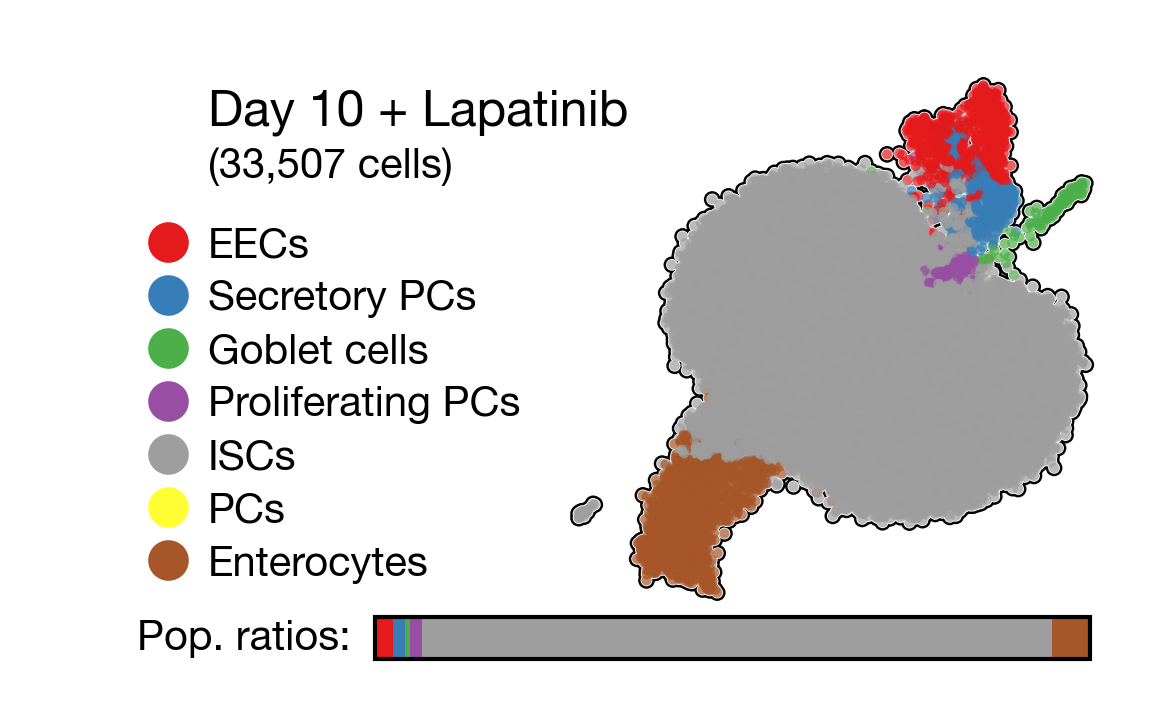

In [ ]:
fig = plot_veres_panel(
    d10_lapa_eecs,
    label_key="initial_cellassign_prediction",
    stage_text="Day 10 + Lapatinib",
    label_order=cats,
    ratio_order=cats
)


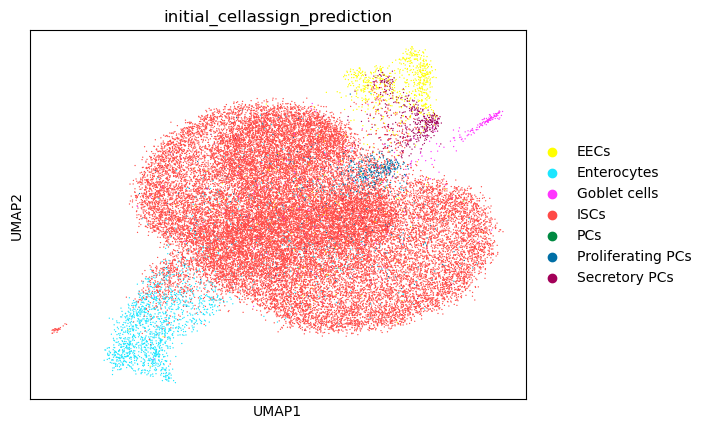

In [ ]:
sc.pl.umap(d10_lapa_eecs, color = 'initial_cellassign_prediction', palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
)

##### Trying to use the palette I've defined in my utils

#### Additions

In [4]:
from matplotlib.colors import to_rgb

def make_label_params(category_names, palette=None):
    """
    Build label->dict(color, short_label) map.
    If `palette` is provided (dict label -> hex), use it where available,
    otherwise fall back to the Veres palettes.
    """
    fallback = (Set1_9.colors + Paired_10.colors[::2] + Set2_8.colors)

    lp = OrderedDict()
    fb_i = 0
    for name in category_names:
        if palette is not None and name in palette:
            # hex -> (r,g,b) in [0,1]
            col = np.array(to_rgb(palette[name]))
        else:
            # fallback palette values are 0..255 ints
            col = _col(fallback[fb_i % len(fallback)])
            fb_i += 1

        lp[name] = dict(color=col, short_label=name)

    return lp


In [ ]:
from src.palette import celltype_palette

In [6]:
celltype_palette = celltype_palette

In [7]:
# --- Veres-style panel builder (Scanpy/AnnData) ---

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
from collections import Counter, OrderedDict
from sklearn.neighbors import NearestNeighbors
from palettable.colorbrewer.qualitative import Set1_9, Paired_10, Set2_8

# -------------------- typography to match paper --------------------
def setup_matplotlib_params():
    from matplotlib import rcParams
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans']
    rcParams['axes.titlesize'] = 5
    rcParams['axes.labelsize']  = 5
    rcParams['xtick.labelsize'] = 5
    rcParams['ytick.labelsize'] = 5
    rcParams['axes.linewidth']  = 0.5
    rcParams['xtick.major.width'] = 0.5
    rcParams['ytick.major.width'] = 0.5
    rcParams['pdf.fonttype'] = 42  # editable text in Illustrator

setup_matplotlib_params()

# -------------------- core color registry (as in figure_vis.py) --------------------
def _col(x): return np.array(x)/255.

class CoreColors:
    def __init__(self):
        base = dict(zip(
            ['red','blue','green','purple','orange','yellow','brown','pink','grey'],
            Set1_9.colors
        ))
        for k,v in base.items(): setattr(self, k, _col(v))
        for name,c in zip(['blue','green','red','orange','purple'], Paired_10.colors[::2]):
            setattr(self, 'pale_'+name, _col(c))
        self.teal        = _col(Set2_8.colors[0])
        self.pale_brown  = _col([193,128,108])
        self.light_grey  = _col(Set2_8.colors[-1])
        self.dark_green  = _col([52,117,50])
        self.dark_grey   = np.array([0.5,0.5,0.5])

core_colors = CoreColors()

# -------------------- label params (you can fully customize) --------------------
def make_label_params(category_names, palette=None):
    """
    Build label->dict(color, short_label) map.
    If `palette` is provided (dict label -> hex), use it where available,
    otherwise fall back to the Veres palettes.
    """
    fallback = (Set1_9.colors + Paired_10.colors[::2] + Set2_8.colors)

    lp = OrderedDict()
    fb_i = 0
    for name in category_names:
        if palette is not None and name in palette:
            # hex -> (r,g,b) in [0,1]
            col = np.array(to_rgb(palette[name]))
        else:
            # fallback palette values are 0..255 ints
            col = _col(fallback[fb_i % len(fallback)])
            fb_i += 1

        lp[name] = dict(color=col, short_label=name)

    return lp
# -------------------- identical logic: sort to put homogeneous neighborhoods on top --------------------
def prepare_for_scatter(X, labels, label_params):
    labels = np.asarray(labels)
    nbrs = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(X)
    knn = nbrs.kneighbors(X, return_distance=False)
    # fraction of neighbors with the same label; sort so dense/consistent are on top
    same = (labels[knn].T == labels[knn][:,0].T).mean(0)
    order = np.argsort(same)
    # map labels -> RGB
    colors = np.ones((len(labels),3))*0.5
    for k,v in label_params.items():
        colors[labels==k] = v['color']
    return X[order], colors[order]

# -------------------- the panel function (ports the notebook code) --------------------
def plot_veres_panel(
    adata,
    label_key,                 # e.g. "initial_cellassign_prediction_colors"
    stage_text=None,           # e.g. "D10_Lapa"
    ratio_order=None,          # list specifying order in pop-bar (optional)
    label_order=None,  # legend order (optional)
    palette = None,        #### ADDED
    save=None,                 # path to .pdf/.png
    dpi=600
):
    # coords & labels
    X = adata.obsm['X_umap']
    labels = adata.obs[label_key].astype(str).values
    cats = list(pd.unique(labels)) if label_order is None else label_order

    # label params (color + short label)
    lp = make_label_params(cats, palette=palette) #### CHANGED

    # ===== panel sizing exactly like their notebook =====
    mm_per_inch = 25.4
    panel_size_in = ((89/2)/mm_per_inch, 25.4/mm_per_inch)  # (W, H)
    cell_pop_bar_h = 0.07
    heights = ((1 - cell_pop_bar_h)*panel_size_in[1], cell_pop_bar_h*panel_size_in[1])
    widths  = (panel_size_in[0] - heights[0], heights[0])  # legend column narrower than scatter

    fig = plt.figure(figsize=panel_size_in, dpi=dpi)
    gs  = gridspec.GridSpec(2, 2, fig, 0,0,1,1,
                            hspace=0, wspace=0,
                            width_ratios=widths, height_ratios=heights)

    # ===== left column: title + legend (with colored dots) =====
    ax = fig.add_subplot(gs[0,0], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)
    li = 1
    yl = lambda i: 1 - i/10.5
    xl_dot, xl_head, xl_text = 0.22, 0.30, 0.30

    # Title ("Stage X" in Veres; we show stage_text and n_cells)
    if stage_text is None:
        stage_text = ""
    ax.text(xl_head, yl(li), f"{stage_text}", va='center', fontsize=6, fontweight='extra bold', clip_on=False)
    li += 1
    ax.text(xl_head, yl(li), f"({adata.n_obs:,} cells)", va='center', fontsize=5, clip_on=False)
    li += 1.5

    present = [c for c in (label_order or cats) if c in set(labels)]
    for lb in present:
        lb_txt = lp[lb]['short_label']
        ax.scatter(xl_dot, yl(li)+0.008, s=15, c=lp[lb]['color'].reshape(1,-1), clip_on=False)
        for line in str(lb_txt).splitlines():
            ax.text(xl_text, yl(li), line, va='center', fontsize=5, clip_on=False)
            li += 1

    # ===== right column: layered scatter (black -> white -> color), alpha as in notebook =====
    proj, rgb = prepare_for_scatter(X, labels, lp)
    ax = fig.add_subplot(gs[0,1], xticks=[], yticks=[], frameon=False, zorder=-1)
    ax.patch.set_visible(False)

    s_black, s_white, s_type = 4, 2, 1.5   # EXACT dot sizes used in the notebook
    ax.scatter(proj[:,0], proj[:,1], c='k', edgecolor='none', s=s_black, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c='w', edgecolor='none', s=s_white, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c=rgb, edgecolor='none', s=s_type, alpha=0.7, rasterized=True)

    # ===== bottom row: population ratio bar (with border rectangle and label) =====
    ax = fig.add_subplot(gs[1,0:2], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)

    counts = pd.Series(Counter(labels))
    fracs  = counts / counts.sum()
    rr = ratio_order or present  # if no ratio_order, follow legend order

    cumul = 0.0
    for lb in rr:
        if lb in fracs:
            w = float(fracs[lb])
            ax.add_patch(patches.Rectangle((0.30 + 0.68*cumul, 0.02), 0.68*w, 1.0,
                                           facecolor=lp[lb]['color'], edgecolor='none', clip_on=False))
            cumul += w

    ax.text(0.175, 0.5, 'Pop. ratios:', va='center', ha='center', fontsize=5, clip_on=False)
    ax.add_patch(patches.Rectangle((0.30, 0.02), 0.68, 1.0, facecolor='none', edgecolor='k', linewidth=0.5, clip_on=False))

    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=dpi, transparent=True, bbox_inches='tight')
    return fig


In [8]:
celltypes_to_plot = [
    "EECs", "Secretory PCs", "Goblet cells",
    "Proliferating PCs", "ISCs", "PCs", "Enterocytes"
]


/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_57818/3817151729.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


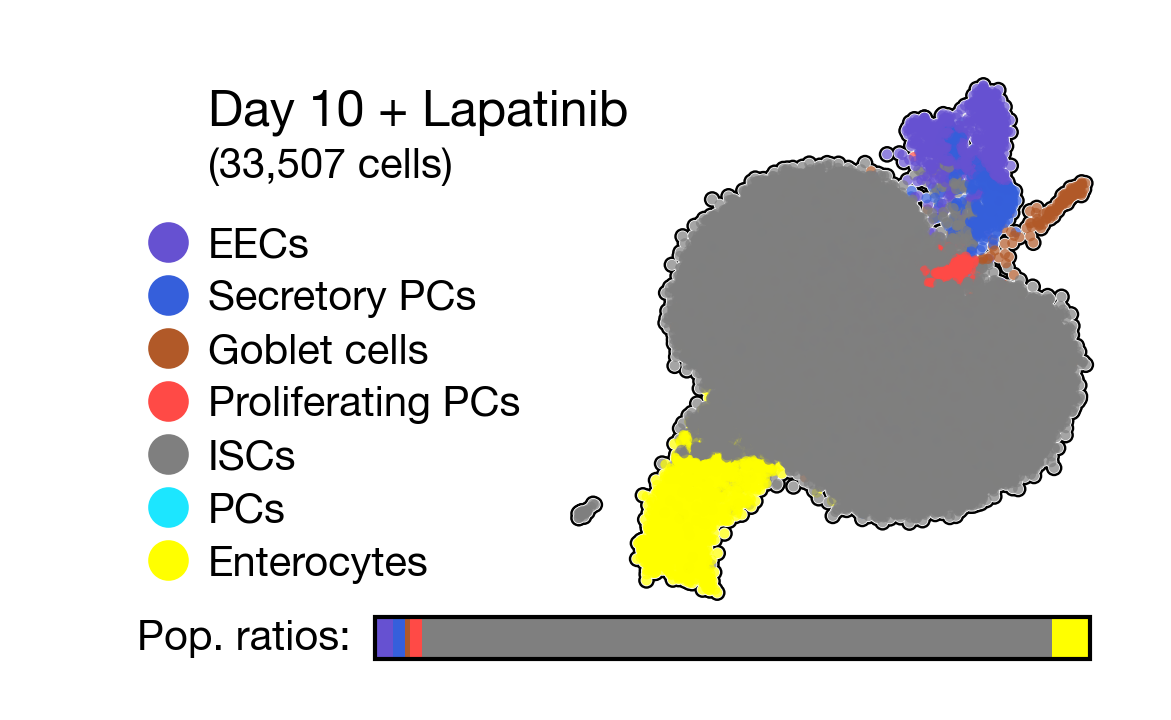

In [9]:
# Your schema
STAGE = "D10_Lapa"
LABEL_KEY = "initial_cellassign_prediction"  # or your final label column

# Optional: lock display order (legend + pop-bar) to your preferred sequence
label_order = [
    "EECs", "Secretory PCs", "Goblet cells",
    "Proliferating PCs", "ISCs", "PCs", "Enterocytes"
]
ratio_order = label_order  # can be different if you wish

# Subset if you had multiple stages; otherwise just pass your AnnData
fig = plot_veres_panel(
    d10_lapa_eecs, 
    label_key=LABEL_KEY,
    stage_text="Day 10 + Lapatinib",
    label_order=label_order,   # or None to use dataset order
    ratio_order=ratio_order,
    palette=celltype_palette,
    save="D10_Lapa_veres_panel.pdf"
)
